In [3]:
import pybamm as pb
import matplotlib.pyplot as plt
import numpy as np

### Plotting the composite model data:

1. To compare with graphite model, which only has temp sweep at 1C
    - sort the composite model data by C-rate
    - take the 1C data and compare with graphite model at different temperatures

2. Looking at information within the composite model
    - Separate the outputs into primary particle and secondary particle contributions
    - 


In [4]:
# load all the saved solutions 
temps = list(np.asarray([-10, 0, 25, 40]) + 273.15)
labels = ["-10$^o$C", "0$^o$C", "25$^o$C", "40$^o$C"]
print(f"labels: {labels}")

solution_set = []

C_rates = ["0.1C", "0.5C", "1C", "2C"]
for C in C_rates:
    for temp in temps:
        sol = pb.load(f"composite_VK_{C}_{temp}K_5cycles.pkl")
        solution_set.append(sol)
        print(f"{C}, {temp}")

# group the solutions by C-rate and label them in a dict    
grouped_solutions = {}
group_size = len(temps)

for i in range(0, len(solution_set), group_size):
    group_key = f"{C_rates[(i // group_size)]}"
    grouped_solutions[group_key] = solution_set[i:i + group_size]

print(solution_set)
print(grouped_solutions)

labels: ['-10$^o$C', '0$^o$C', '25$^o$C', '40$^o$C']
0.1C, 263.15
0.1C, 273.15
0.1C, 298.15
0.1C, 313.15
0.5C, 263.15
0.5C, 273.15
0.5C, 298.15
0.5C, 313.15
1C, 263.15
1C, 273.15
1C, 298.15
1C, 313.15
2C, 263.15
2C, 273.15
2C, 298.15
2C, 313.15
[<pybamm.solvers.solution.Solution object at 0x0000020ED0B56E40>, <pybamm.solvers.solution.Solution object at 0x0000020ED092B200>, <pybamm.solvers.solution.Solution object at 0x0000020ED0A2A1B0>, <pybamm.solvers.solution.Solution object at 0x0000020EC7CA5550>, <pybamm.solvers.solution.Solution object at 0x0000020ED0B748C0>, <pybamm.solvers.solution.Solution object at 0x0000020ED95B1BB0>, <pybamm.solvers.solution.Solution object at 0x0000020EDF1F8980>, <pybamm.solvers.solution.Solution object at 0x0000020ED0870DA0>, <pybamm.solvers.solution.Solution object at 0x0000020ED51A1610>, <pybamm.solvers.solution.Solution object at 0x0000020EFCF78D40>, <pybamm.solvers.solution.Solution object at 0x0000020EA97E4F50>, <pybamm.solvers.solution.Solution objec

Text(0, 0.5, 'Loss of lithium inventory [mol]')

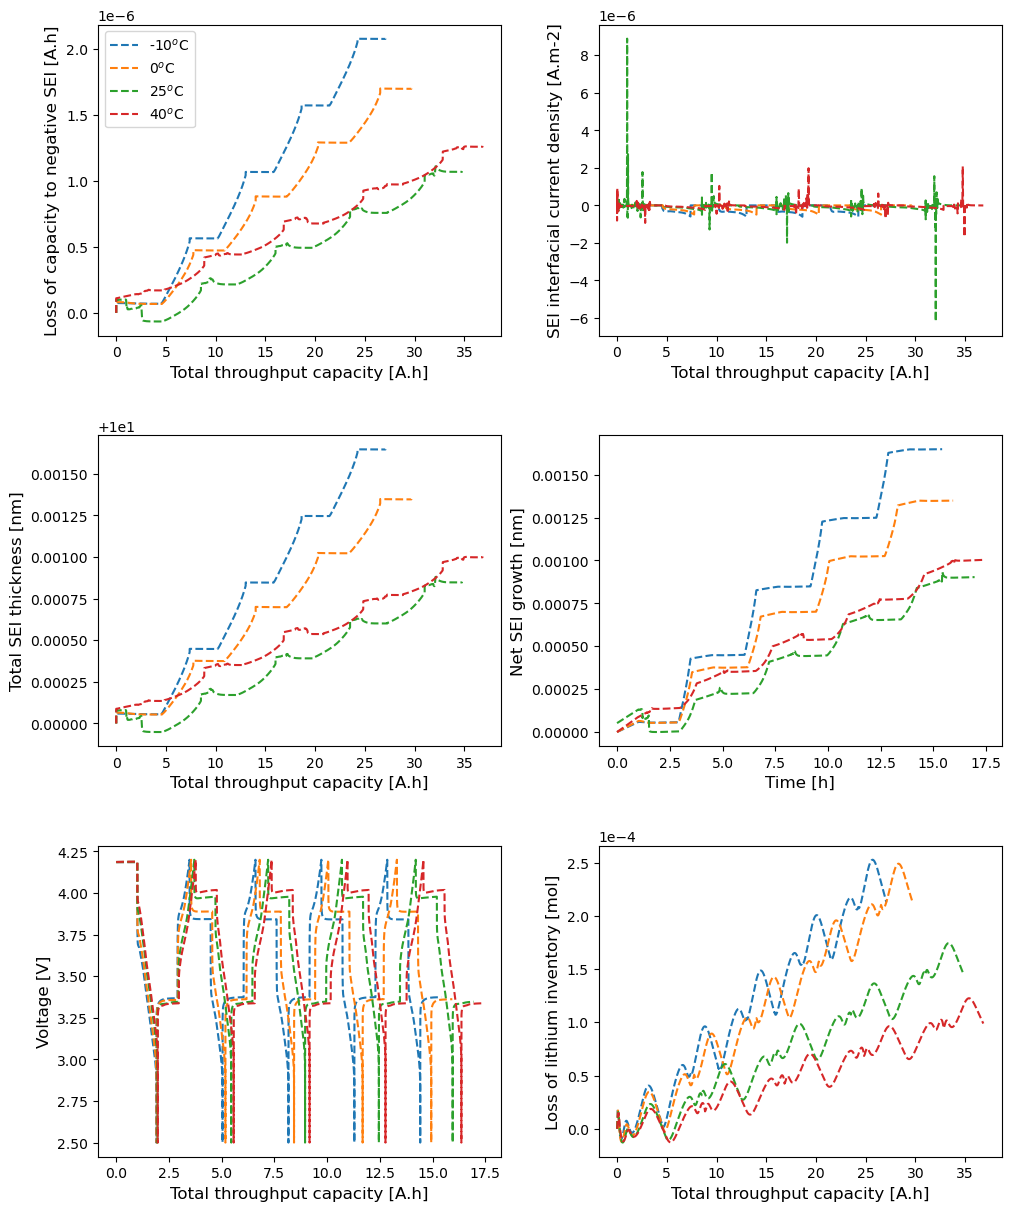

In [11]:
################################
# plotting the combined effect #
################################

# take the data from 1C 
sols = grouped_solutions["1C"]

fig, axes = plt.subplots(3,2, layout="constrained", figsize=(10,12), gridspec_kw={"hspace": 0.1}, sharex=False)
plt.ticklabel_format(style="sci", axis="y", scilimits=(0,0))

for index, sol in enumerate(sols):
    # independent variable
    Q_tot = sol["Throughput capacity [A.h]"].entries
    t = sol["Time [h]"].entries

    # various dependent variables
    Q_SEI = sol["Loss of capacity to negative SEI [A.h]"].entries
    # current densities
    J_SEI_1 = sol["X-averaged negative electrode primary SEI interfacial current density [A.m-2]"].entries
    J_SEI_2 = sol["X-averaged negative electrode secondary SEI interfacial current density [A.m-2]"].entries
    J_SEI = (J_SEI_1 + J_SEI_2)
    
    V_i = sol["Voltage [V]"].entries
    # electrolyte_V = sol["Electrolyte potential [V]"].entries
    C_dis = sol["Discharge capacity [A.h]"].entries
    
    # LLI
    Q_LLI = sol["Total lithium lost [mol]"].entries #*96485.3 / 3600
    
    # SEI thickness of composite phases
    L_SEI_1 = (sol["X-averaged negative total primary SEI thickness [m]"].entries)*1e9
    L_SEI_2 = (sol["X-averaged negative total secondary SEI thickness [m]"].entries)*1e9
    L_SEI = (L_SEI_1 + L_SEI_2)
    L_min = np.min(L_SEI)
    delta_L = (L_SEI - L_min)

    # plot graph on the go
    axes[0][0].plot(Q_tot, Q_SEI, label = f"{labels[index]}",linestyle="--")
    axes[0][1].plot(Q_tot, J_SEI, label = f"{labels[index]}",linestyle="--")
    axes[1][0].plot(Q_tot, L_SEI, label = f"{labels[index]}",linestyle="--")
    axes[1][1].plot(t, delta_L, label = f"{labels[index]}",linestyle="--")
    axes[2][0].plot(t, V_i, label = f"{labels[index]}",linestyle="--")
    axes[2][1].plot(Q_tot, Q_LLI, label = f"{labels[index]}",linestyle="--")
    
# graph formatting
# Right side:
axes[0][0].set_xlabel("Total throughput capacity [A.h]", fontsize=12)
axes[0][0].set_ylabel("Loss of capacity to negative SEI [A.h]", fontsize=12) 
axes[0][0].legend()

axes[1][0].set_xlabel("Total throughput capacity [A.h]", fontsize=12)
axes[1][0].set_ylabel("Total SEI thickness [nm]", fontsize=12)

axes[2][0].set_xlabel("Total throughput capacity [A.h]", fontsize=12)
axes[2][0].set_ylabel("Voltage [V]", fontsize=12)

# Left side: 
axes[0][1].set_xlabel("Total throughput capacity [A.h]", fontsize=12)
axes[0][1].set_ylabel("SEI interfacial current density [A.m-2]", fontsize=12)

axes[1][1].set_xlabel("Time [h]", fontsize=12)
axes[1][1].set_ylabel("Net SEI growth [nm]", fontsize=12)

axes[2][1].set_xlabel("Total throughput capacity [A.h]", fontsize=12)
axes[2][1].set_ylabel("Loss of lithium inventory [mol]", fontsize=12)

Text(0, 0.5, 'Current [A]')

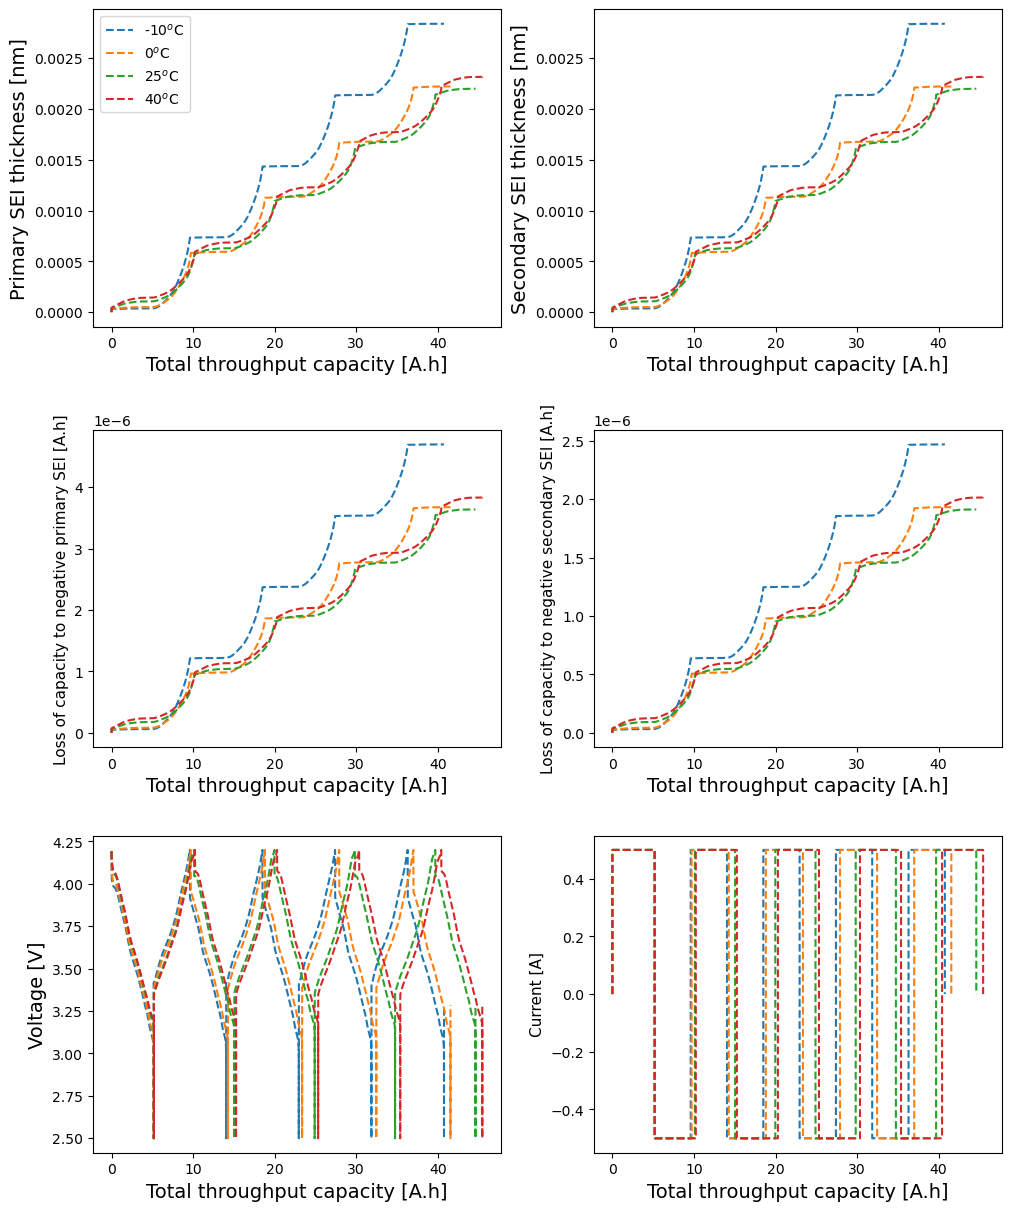

In [6]:
##############################
# plotting individual phases #
##############################

# take the data from 1C 
sols = grouped_solutions["0.1C"]      # ["2C", "1C", "0.5C", "0.1C"]

fig, axes = plt.subplots(3,2, layout="constrained", figsize=(10,12), gridspec_kw={"hspace": 0.1}, sharex=False)


for index, sol in enumerate(sols):
    # independent variable
    Q_tot = sol["Throughput capacity [A.h]"].entries
    t = sol["Time [h]"].entries

    # various dependent variables
    Q_SEI = sol["Loss of capacity to negative SEI [A.h]"].entries
    Q_SEI_1 = sol["Loss of capacity to negative primary SEI [A.h]"].entries
    Q_SEI_2 = sol["Loss of capacity to negative secondary SEI [A.h]"].entries

    # current densities
    J_SEI_1 = sol["X-averaged negative electrode primary SEI interfacial current density [A.m-2]"].entries
    J_SEI_2 = sol["X-averaged negative electrode secondary SEI interfacial current density [A.m-2]"].entries
    J_SEI = (J_SEI_1 + J_SEI_2)
    
    # voltage
    I_tot = sol["Current [A]"].entries
    V_i = sol["Voltage [V]"].entries
    # electrolyte_V = sol["Electrolyte potential [V]"].entries
    C_dis = sol["Discharge capacity [A.h]"].entries
    
    # LLI
    Q_LLI = sol["Total lithium lost [mol]"].entries #*96485.3 / 3600
    
    # SEI thickness of composite phases
    L_SEI_1 = (sol["X-averaged negative total primary SEI thickness [m]"].entries)*1e9
    L_SEI_2 = (sol["X-averaged negative total secondary SEI thickness [m]"].entries)*1e9
    delta_L_SEI_1 = L_SEI_1 - np.min(L_SEI_1)
    delta_L_SEI_2 = L_SEI_2 - np.min(L_SEI_2)


    # RHS - Gr
    axes[0][0].plot(Q_tot, delta_L_SEI_1, label = f"{labels[index]}",linestyle="--",)
    axes[1][0].plot(Q_tot, Q_SEI_1, label = f"{labels[index]}",linestyle="--")
    axes[2][0].plot(Q_tot, V_i, label = f"{labels[index]}",linestyle="--")
    #LHS - Si
    axes[0][1].plot(Q_tot, delta_L_SEI_2, label = f"{labels[index]}",linestyle="--")
    axes[1][1].plot(Q_tot, Q_SEI_2, label = f"{labels[index]}",linestyle="--")
    axes[2][1].plot(Q_tot, I_tot, label = f"{labels[index]}",linestyle="--")
    
# graph formatting
# Right side:
axes[0][0].set_xlabel("Total throughput capacity [A.h]", fontsize=14)
axes[0][0].set_ylabel("Primary SEI thickness [nm]", fontsize=14) 
axes[0][0].legend(loc="upper left")

axes[1][0].set_xlabel("Total throughput capacity [A.h]", fontsize=14)
axes[1][0].set_ylabel("Loss of capacity to negative primary SEI [A.h]", fontsize=11)

axes[2][0].set_xlabel("Total throughput capacity [A.h]", fontsize=14)
axes[2][0].set_ylabel("Voltage [V]", fontsize=14)

# Left side: 
axes[0][1].set_xlabel("Total throughput capacity [A.h]", fontsize=14)
axes[0][1].set_ylabel("Secondary SEI thickness [nm]", fontsize=14)

axes[1][1].set_xlabel("Total throughput capacity [A.h]", fontsize=14)
axes[1][1].set_ylabel("Loss of capacity to negative secondary SEI [A.h]", fontsize=11)

axes[2][1].set_xlabel("Total throughput capacity [A.h]", fontsize=14)
axes[2][1].set_ylabel("Current [A]", fontsize=11)


In [7]:
print(f"{Q_SEI} \n{Q_SEI_1} \n{Q_SEI_2}")
print(f"{L_SEI} \n{L_SEI_1} \n{L_SEI_2}")

[-1.73472348e-18  1.09147032e-11  2.07387102e-11 ...  5.84660931e-06
  5.84675482e-06  5.84682667e-06] 
[-1.73472348e-18  7.15381573e-12  1.35927554e-11 ...  3.83203872e-06
  3.83213408e-06  3.83218118e-06] 
[0.00000000e+00 3.76088743e-12 7.14595483e-12 ... 2.01457059e-06
 2.01462073e-06 2.01464549e-06]
[10.         10.00000001 10.00000002 ... 10.00463538 10.0046355
 10.00463556] 
[5.         5.         5.00000001 ... 5.00231769 5.00231775 5.00231778] 
[5.         5.         5.00000001 ... 5.00231769 5.00231775 5.00231778]
